# Descriptives: attitudes
This notebook creates plots of climate attitudes.

In [1]:
# Set up
import pandas as pd
import numpy as np
import sys
from pathlib import Path
CODE_ROOT = Path.cwd().parents[1]
sys.path.append(str(CODE_ROOT))
import config
from openpyxl import Workbook
from openpyxl.styles import Alignment
import os
import matplotlib.pyplot as plt
import textwrap
import re
import statsmodels.formula.api as smf
from IPython.display import display

# Global plotting font
plt.rcParams["font.family"] = "Arial"

In [2]:
# Load data
labs = pd.read_csv(
    config.PROCESSED_DATA / "individual_processed_4.csv",
    keep_default_na=False,  # Keep "None" as a string, not NaN
    na_values=[""] # Only treat empty strings as NaN
)
equipment = pd.read_csv(
    config.PROCESSED_DATA / "panel_processed_2.csv",
    keep_default_na=False,  # Keep "None" as a string, not NaN
    na_values=[""] # Only treat empty strings as NaN
)

In [3]:
# Keep only relevant columns (attitude_q_1, attitude_q_2, ..., labgroupid, faculty, Treatment Status)
labs = labs[["labgroupid", "faculty", "institute", 
             "Treatment Status", "enum_id", "no_researchers", 
             "calc_total_energy"] +
             [col for col in labs.columns if col.startswith("attitude_q_")]]

# Keep only rows where answered at least one of the attitude questions
labs = labs.dropna(subset=[col for col in labs.columns if col.startswith("attitude_q_")], how="all")

In [4]:
# Attitude question labels
question_labels = [
    "Universities have a responsibility to reduce their environmental impact",
    "Research groups consume more energy/resources than necessary",
    "I try to consider sustainability when making decisions in my group",
    "Sustainability requirements risk slowing down scientific research",
    "Sustainable research practices can improve research quality/efficiency",
    "I am aware of the energy/resource costs of my group's activities",
    "I would be more motivated if my group directly faced the financial costs",
    "Top-down initiatives are more effective than bottom-up ones",
]

In [5]:
# Plot typography
plot_font = "Arial"
plt.rcParams["font.family"] = plot_font
plt.rcParams["font.size"] = 13

In [6]:
# Output folder paths
output_folder = config.OUTPUT / "3_Attitudes"
output_folder.mkdir(parents=True, exist_ok=True)

In [7]:
# Histograms of attitude questions

# Define the correct order for attitude responses
attitude_order = ["Strongly disagree", "Disagree", "Neither agree nor disagree", "Agree", "Strongly agree"]

attitude_cols = [col for col in labs.columns if col.startswith("attitude_q_")]

# Version 1: pooled - shares of all respondents
for col in attitude_cols:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Calculate share of all respondents
    value_counts = labs[col].value_counts()
    value_counts = value_counts.reindex(attitude_order, fill_value=0)
    shares = (value_counts / labs[col].notna().sum()) * 100
    
    shares.plot(kind="bar", ax=ax, color="skyblue", edgecolor="black", linewidth=1.2)
    ax.set_title(f"Distribution of responses for {col}", fontsize=14)
    ax.set_xlabel("Response", fontsize=12)
    ax.set_ylabel("Share (%)", fontsize=12)
    ax.set_xticklabels(attitude_order, rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(output_folder / f"{col}_pooled.pdf")
    plt.close()

# Version 2: control vs treatment - shares per treatment group
import numpy as np
for col in attitude_cols:
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Prepare data for both groups
    control_data = labs[labs["Treatment Status"] == "control"][col]
    treatment_data = labs[labs["Treatment Status"] == "treatment"][col]
    
    control_counts = control_data.value_counts().reindex(attitude_order, fill_value=0)
    treatment_counts = treatment_data.value_counts().reindex(attitude_order, fill_value=0)
    
    control_shares = (control_counts / control_data.notna().sum()) * 100
    treatment_shares = (treatment_counts / treatment_data.notna().sum()) * 100
    
    # Set up bar positions
    x = np.arange(len(attitude_order))
    width = 0.35
    
    ax.bar(x - width/2, control_shares, width, label="Control", color="skyblue", edgecolor="black", linewidth=1.2)
    ax.bar(x + width/2, treatment_shares, width, label="Treatment", color="lightcoral", edgecolor="black", linewidth=1.2)
    
    ax.set_title(f"{col}", fontsize=14)
    ax.set_ylabel("Share (%)", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(attitude_order, rotation=45, ha="right")
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(output_folder / f"{col}_ct.pdf")
    plt.close()


In [8]:
# Stacked horizontal bar chart showing composition for each attitude question (pooled and control)

for x in ["pooled", "control"]:
    if x == "pooled":
        data_subset = labs
    if x == "control":
        data_subset = labs[labs["Treatment Status"] == "control"]

    attitude_order = ["Strongly disagree", "Disagree", "Neither agree nor disagree", "Agree", "Strongly agree"]
    attitude_cols = sorted(
        [col for col in data_subset.columns if col.startswith("attitude_q_")],
        key=lambda x: int(x.split("_")[-1])
    )

    # Wrap long labels so they fit on the figure
    question_labels_wrapped = [textwrap.fill(lbl, width=45) for lbl in question_labels]

    # Define colors for each response type (agreement in blue shades)
    colors = ["#d73027", "#fc8d59", "#fee090", "#9ecae1", "#2171b5"]

    fig, ax = plt.subplots(figsize=(14, 8))

    # Prepare data for stacked bar chart
    data_for_plot = []
    for col in attitude_cols:
        value_counts = data_subset[col].value_counts()
        value_counts = value_counts.reindex(attitude_order, fill_value=0)
        shares = (value_counts / data_subset[col].notna().sum()) * 100
        data_for_plot.append(shares.values)

    data_for_plot = np.array(data_for_plot)
    # Ensure each row ends exactly at 100 despite floating-point precision
    data_for_plot = data_for_plot / data_for_plot.sum(axis=1, keepdims=True) * 100

    # Create stacked horizontal bars
    y_pos = np.arange(len(attitude_cols))
    left = np.zeros(len(attitude_cols))

    for i, response in enumerate(attitude_order):
        ax.barh(y_pos, data_for_plot[:, i], left=left, label=response, color=colors[i], edgecolor="black", linewidth=0.5)
        left += data_for_plot[:, i]

    # Show Q1 at top and Q8 at bottom
    ax.set_yticks(y_pos)
    ax.set_yticklabels(question_labels_wrapped, fontsize=15)
    ax.invert_yaxis()

    ax.tick_params(axis="x", labelsize=15)
    ax.tick_params(axis="y", length=0)
    ax.set_xlabel("Share of labs (%)", fontsize=15)
    ax.set_xlim(0, 100)
    ax.margins(x=0)
    ax.set_xticks(np.arange(0, 101, 20))

    # Remove frame lines that extend above/below bars
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.grid(axis="x", alpha=0.3)
    # Explicit 100 line, drawn above bars so it is visible
    ax.axvline(100, color="#b0b0b0", linewidth=1.0, alpha=0.45, zorder=6, clip_on=False)

    # Black end-caps at the end of each bar
    bar_half_height = 0.4
    for y in y_pos:
        ax.vlines(100, y - bar_half_height, y + bar_half_height, color="black", linewidth=1.1, zorder=7)

    # Reduce blank space at right; keep room for long y labels and bottom legend
    fig.subplots_adjust(left=0.43, right=0.995, bottom=0.2)

    # Center legend on the same horizontal centerline as x-axis label
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=5, fontsize=12)

    plt.tight_layout()
    plt.savefig(output_folder / f"attitude_bar_char_{x}.pdf", bbox_inches="tight")
    plt.close()


In [9]:

# Regressions of attitudes on treatment status, controlling for faculty, no researchers, calculated energy

# 1) Prepare analysis dataframe

# Recode attitude responses to numeric scale
attitude_map = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neither agree nor disagree": 3,
    "Agree": 4,
    "Strongly agree": 5,
}

# Keep attitude variables in numerical order
attitude_cols = sorted(
    [c for c in labs.columns if c.startswith("attitude_q_")],
    key=lambda x: int(re.search(r"(\d+)$", x).group(1))
)

# Control variables
faculty_col = "faculty"
researchers_col = "no_researchers"
energy_col = "calc_total_energy"
enum_col = "enum_id"
treat_col = "Treatment Status"


# Create analysis df
reg_base = labs.copy()
reg_base["treat"] = reg_base[treat_col].astype(str).str.strip().str.lower().map({"treatment": 1, "control": 0})
reg_base[researchers_col] = pd.to_numeric(reg_base[researchers_col], errors="coerce")
reg_base[energy_col]      = pd.to_numeric(reg_base[energy_col], errors="coerce")

# Initialize list to store regression results
results_summary = []

# 2) Run regressions and print results

# For each attitude question, run regression on treatment status controlling for faculty, no researchers, calculated energy
for att_col in attitude_cols:
    reg_df = reg_base[[att_col, "treat", faculty_col, researchers_col, energy_col] + ([enum_col] if enum_col else [])].copy()
    reg_df["y"] = reg_df[att_col].map(attitude_map)
    reg_df = reg_df.dropna(subset=["y", "treat", faculty_col, researchers_col, energy_col])

    if reg_df.empty:
        continue

    formula = f'y ~ treat + C(Q("{faculty_col}")) + Q("{researchers_col}") + Q("{energy_col}")'
    model   = smf.ols(formula=formula, data=reg_df)

    # SE choice: cluster by enumerator if feasible, else HC1 robust
    use_cluster = False
    cov_note    = "HC1 robust"
    fitted      = None

    if enum_col and enum_col in reg_df.columns:
        groups = reg_df[enum_col]
        n_clusters = groups.nunique(dropna=True)
        if n_clusters >= 2 and groups.value_counts(dropna=True).max() >= 2:
            try:
                fitted = model.fit(cov_type="cluster", cov_kwds={"groups": groups, "use_correction": True})
                use_cluster = True
                cov_note = f"Clustered ({enum_col}, n={n_clusters})"
            except Exception:
                fitted = model.fit(cov_type="HC1")
        else:
            fitted = model.fit(cov_type="HC1")
    else:
        fitted = model.fit(cov_type="HC1")

    coef_table  = fitted.summary2().tables[1]
    treat_row   = coef_table.loc["treat"]
    p_col       = "P>|t|" if "P>|t|" in coef_table.columns else "P>|z|"

    results_summary.append({
        "Outcome":        att_col,
        "Treat coef":     round(treat_row["Coef."],    3),
        "SE":             round(treat_row["Std.Err."], 3),
        "p-value":        round(treat_row[p_col],      3),
        "Control mean":   round(reg_df.loc[reg_df["treat"] == 0, "y"].mean(), 3),
        "N":              int(fitted.nobs),
    })

if results_summary:
    summary_df = pd.DataFrame(results_summary).set_index("Outcome")
    display(summary_df)


,Treat coef,SE,p-value,Control mean,N
Outcome,,,,,
attitude_q_1,-0.018,0.124,0.883,4.273,91
attitude_q_2,-0.015,0.154,0.921,3.068,91
attitude_q_3,0.060,0.167,0.718,3.955,91
attitude_q_4,-0.095,0.203,0.641,2.841,91
attitude_q_5,0.319,0.196,0.103,2.886,91
attitude_q_6,0.418,0.165,0.011,3.273,91
attitude_q_7,-0.529,0.207,0.010,3.500,91
attitude_q_8,0.111,0.186,0.550,3.045,91


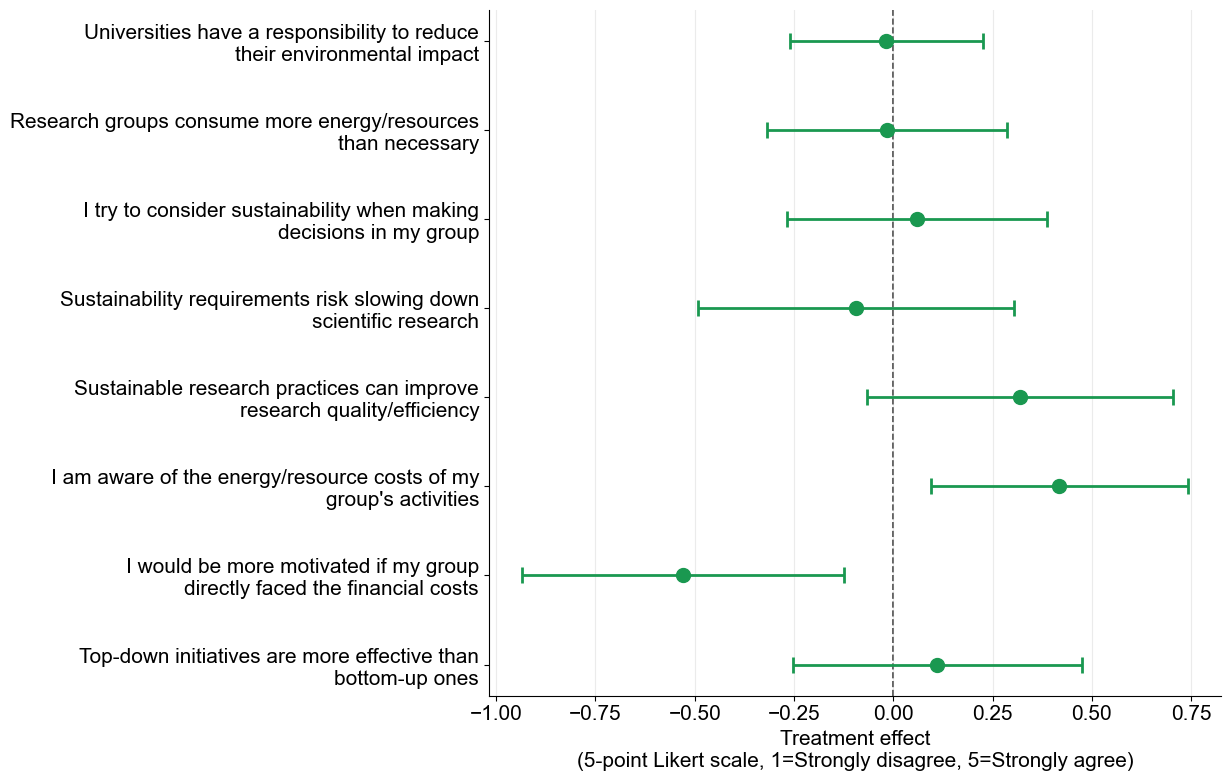

In [10]:
# Coefficient plot

if "summary_df" not in globals() or summary_df is None or len(summary_df) == 0:
    print("Run the regression cell first so summary_df exists.")
else:
    coef_plot_df = summary_df.reset_index().rename(columns={"index": "Outcome"}).copy()

    # Allow either previous naming convention
    if "Outcome" not in coef_plot_df.columns and "outcome" in coef_plot_df.columns:
        coef_plot_df["Outcome"] = coef_plot_df["outcome"]
    if "Treat coef" not in coef_plot_df.columns and "treat_coef" in coef_plot_df.columns:
        coef_plot_df["Treat coef"] = coef_plot_df["treat_coef"]
    if "SE" not in coef_plot_df.columns and "treat_se" in coef_plot_df.columns:
        coef_plot_df["SE"] = coef_plot_df["treat_se"]

    coef_plot_df["q_num"] = coef_plot_df["Outcome"].str.extract(r"(\d+)$").astype(int)
    coef_plot_df = coef_plot_df.sort_values("q_num").reset_index(drop=True)

    # Use same labels as stacked bar chart when available
    if "question_labels" in globals() and len(question_labels) == len(coef_plot_df):
        label_map = {f"attitude_q_{i+1}": question_labels[i] for i in range(len(question_labels))}
        coef_plot_df["Question"] = coef_plot_df["Outcome"].map(label_map)
    else:
        coef_plot_df["Question"] = coef_plot_df["Outcome"]

    coef_plot_df["Question_wrapped"] = coef_plot_df["Question"].apply(lambda s: textwrap.fill(str(s), width=45))
    coef_plot_df["CI95"] = 1.96 * coef_plot_df["SE"]

    y = np.arange(len(coef_plot_df))

    fig, ax = plt.subplots(figsize=(12.5, 8))

    ax.errorbar(
        coef_plot_df["Treat coef"],
        y,
        xerr=coef_plot_df["CI95"],
        fmt="o",
        color="#1a9850",
        ecolor="#1a9850",
        elinewidth=2,
        capsize=6,
        capthick=2,
        markersize=10,
        zorder=3,
    )

    ax.axvline(0, color="#444444", linestyle="--", linewidth=1.2, zorder=1)
    ax.set_yticks(y)
    ax.set_yticklabels(coef_plot_df["Question_wrapped"], fontsize=15)
    ax.invert_yaxis()  # Q1 at top like the bar chart
    ax.set_xlabel("Treatment effect\n(5-point Likert scale, 1=Strongly disagree, 5=Strongly agree)", fontsize=15)
    ax.tick_params(axis="x", labelsize=15)
    ax.grid(axis="x", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(output_folder / "attitude_coef_plot.pdf")
    plt.show()


In [11]:
# Descriptive stats: how many answered Agree or Strongly agree for each question

attitude_cols = sorted(
    [c for c in labs.columns if c.startswith("attitude_q_")],
    key=lambda x: int(re.search(r"(\d+)$", x).group(1))
)

agree_rows = []
for i, att_col in enumerate(attitude_cols, start=1):
    s = labs[att_col]
    non_missing_n = int(s.notna().sum())
    agree_n = int(s.isin(["Agree", "Strongly agree"]).sum())
    agree_share = (agree_n / non_missing_n * 100) if non_missing_n > 0 else np.nan

    question_text = question_labels[i - 1] if "question_labels" in globals() and len(question_labels) >= i else att_col

    agree_rows.append({
        "Question": question_text,
        "Agree/Strongly agree (N)": agree_n,
        "Total non-missing (N)": non_missing_n,
        "Agree/Strongly agree (%)": round(agree_share, 1),
    })

agree_summary_df = pd.DataFrame(agree_rows)

# Optional display tweak for readability
agree_summary_display = agree_summary_df.copy()
agree_summary_display["Question"] = agree_summary_display["Question"].apply(lambda s: textwrap.fill(str(s), width=60))

display(agree_summary_display)

,Question,Agree/Strongly agree (N),Total non-missing (N),Agree/Strongly agree (%)
0,Universities have a responsibility to reduce t...,86,93,92.5
1,Research groups consume more energy/resources ...,30,93,32.3
2,I try to consider sustainability when making d...,74,93,79.6
3,Sustainability requirements risk slowing down ...,23,93,24.7
4,Sustainable research practices can improve res...,28,93,30.1
5,I am aware of the energy/resource costs of my ...,60,93,64.5
6,I would be more motivated if my group directly...,45,93,48.4
7,Top-down initiatives are more effective than b...,39,93,41.9
